# UCT Strength Ladder

Establishes an **absolute playing-strength scale** for our UCT baselines.

**Methodology:** UCT-{10, 50, 100, 500, 2000} vs Random, N=50 games each side
(100 total per match, both colors played to cancel Reversi's first-mover advantage).
Adjacent UCT levels also matched head-to-head to confirm strict monotonicity.

**Why this matters:** "UCT-500" and "UCT-2000" are just labels until we know what
they mean in absolute terms. This calibration lets us place the LLM agent on the
same scale once we measure its win rate vs Random directly.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

ladder    = json.loads(Path("../data/uct_ladder.json").read_text())
vs_random = [r for r in ladder if r["label_b"] == "Random"]
cross     = [r for r in ladder if r["label_b"] != "Random"]

df = pd.DataFrame(ladder)
df[["label_a","label_b","total_games","wins_a","wins_b","draws","win_rate_a","win_rate_b"]]

,label_a,label_b,total_games,wins_a,wins_b,draws,win_rate_a,win_rate_b
0,UCT-10,Random,100,75,20,5,0.75,0.20
1,UCT-50,Random,100,92,3,5,0.92,0.03
2,UCT-100,Random,100,100,0,0,1.00,0.00
3,UCT-500,Random,100,99,1,0,0.99,0.01
4,UCT-2000,Random,100,100,0,0,1.00,0.00
5,UCT-10,UCT-50,100,7,91,2,0.07,0.91
6,UCT-50,UCT-100,100,35,64,1,0.35,0.64
7,UCT-100,UCT-500,100,14,85,1,0.14,0.85
8,UCT-500,UCT-2000,100,20,80,0,0.20,0.80


## 1. Absolute strength scale (vs Random)

Win rate of each UCT-N as either color against a uniform-random opponent.
Error bars are Wilson 95% CIs.

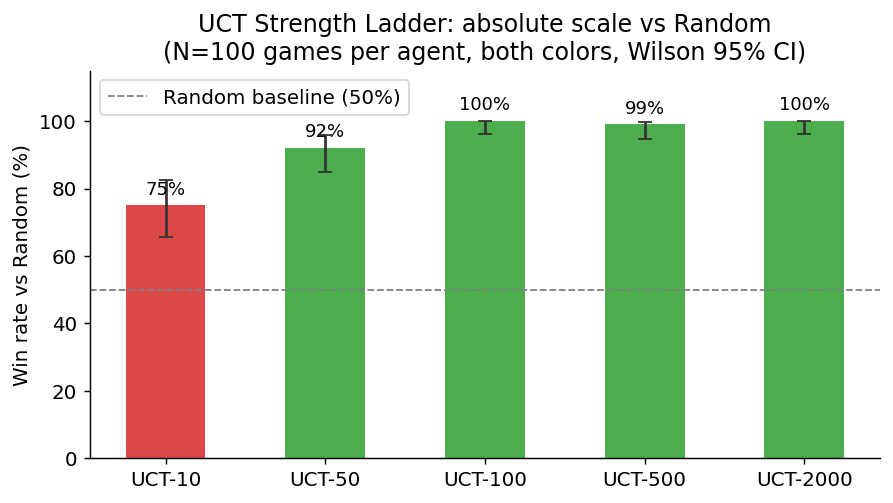

In [2]:
def wilson_ci(wins, n, z=1.96):
    """Wilson score 95% CI for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = wins / n
    denom  = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half   = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

labels    = [r["label_a"] for r in vs_random]
win_rates = [r["win_rate_a"] for r in vs_random]
ns        = [r["total_games"] for r in vs_random]
wins      = [r["wins_a"]      for r in vs_random]

cis     = [wilson_ci(w, n) for w, n in zip(wins, ns)]
yerr_lo = [max(0.0, wr - lo) for wr, (lo, hi) in zip(win_rates, cis)]
yerr_hi = [max(0.0, hi - wr) for wr, (lo, hi) in zip(win_rates, cis)]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728" if wr < 0.9 else "#2ca02c" for wr in win_rates]
bars = ax.bar(labels, [wr * 100 for wr in win_rates], color=colors, alpha=0.85, width=0.5)
ax.errorbar(
    labels, [wr * 100 for wr in win_rates],
    yerr=[np.array(yerr_lo) * 100, np.array(yerr_hi) * 100],
    fmt="none", color="#333", capsize=4, linewidth=1.5,
)
ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="Random baseline (50%)")
ax.set_ylabel("Win rate vs Random (%)")
ax.set_title("UCT Strength Ladder: absolute scale vs Random\n(N=100 games per agent, both colors, Wilson 95% CI)")
ax.set_ylim(0, 115)
ax.legend()
for bar, wr in zip(bars, win_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{wr*100:.0f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("../data/fig_uct_ladder_vs_random.png", bbox_inches="tight")
plt.show()

## 2. Cross-match win rates (monotonicity check)

Each adjacent UCT pair matched head-to-head. The ladder is strictly monotone if
the higher-iteration agent always wins more.

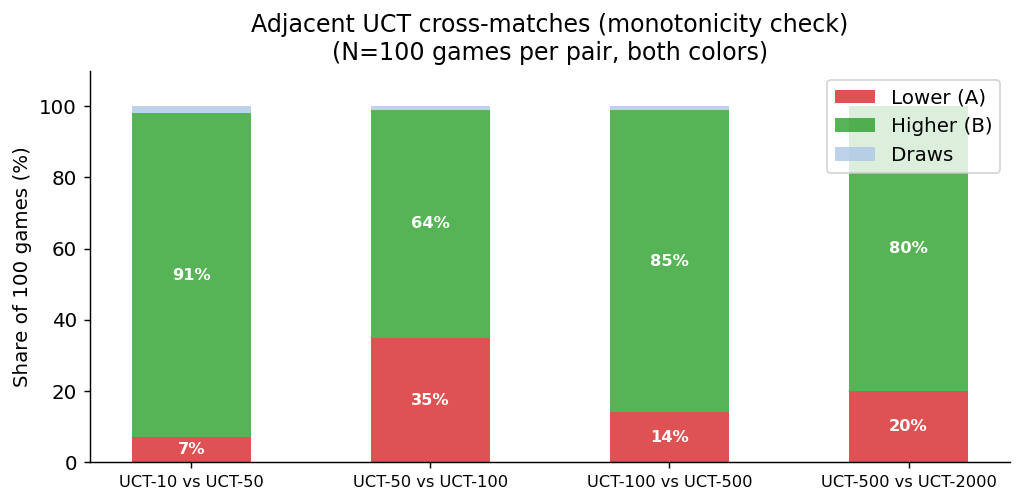

In [3]:
cross_labels = [f"{r['label_a']} vs {r['label_b']}" for r in cross]
win_a    = [r["win_rate_a"] * 100 for r in cross]
win_b    = [r["win_rate_b"] * 100 for r in cross]
draw_pct = [r["draws"] / r["total_games"] * 100 for r in cross]

x = np.arange(len(cross))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, win_a,    label="Lower (A)",  color="#d62728", alpha=0.8, width=0.5)
ax.bar(x, win_b,    bottom=win_a,                   label="Higher (B)", color="#2ca02c", alpha=0.8, width=0.5)
ax.bar(x, draw_pct, bottom=[a+b for a,b in zip(win_a,win_b)], label="Draws", color="#aec7e8", alpha=0.8, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cross_labels, fontsize=9)
ax.set_ylabel("Share of 100 games (%)")
ax.set_title("Adjacent UCT cross-matches (monotonicity check)\n(N=100 games per pair, both colors)")
ax.set_ylim(0, 110)
ax.legend(loc="upper right")
for i, (a, b) in enumerate(zip(win_a, win_b)):
    if a > 5:
        ax.text(x[i], a / 2, f"{a:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    ax.text(x[i], a + b / 2, f"{b:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/fig_uct_cross_matches.png", bbox_inches="tight")
plt.show()

## 3. Placing the LLM on the scale

Preliminary estimate from the B=4096 vs UCT-10 run (N=4 games):
LLM wins 1/4 = 25% vs UCT-10. UCT-10 wins 75% vs Random.
By transitivity, LLM ≈ 55–65% vs Random. **Hatched bars = estimate, not measured.**

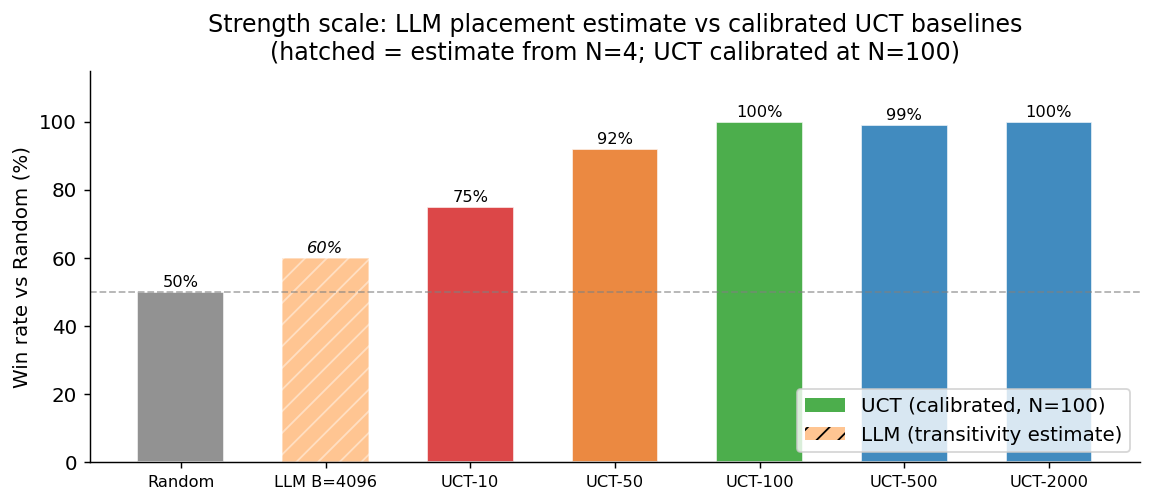

In [4]:
agents = [
    {"label": "Random",      "win_rate": 0.50, "est": False, "color": "#7f7f7f"},
    {"label": "LLM B=4096",  "win_rate": 0.60, "est": True,  "color": "#ff7f0e"},
    {"label": "UCT-10",      "win_rate": 0.75, "est": False, "color": "#d62728"},
    {"label": "UCT-50",      "win_rate": 0.92, "est": False, "color": "#e87520"},
    {"label": "UCT-100",     "win_rate": 1.00, "est": False, "color": "#2ca02c"},
    {"label": "UCT-500",     "win_rate": 0.99, "est": False, "color": "#1f77b4"},
    {"label": "UCT-2000",    "win_rate": 1.00, "est": False, "color": "#1f77b4"},
]

fig, ax = plt.subplots(figsize=(9, 4))
for i, ag in enumerate(agents):
    alpha, hatch = (0.45, "//") if ag["est"] else (0.85, None)
    ax.bar(i, ag["win_rate"] * 100, color=ag["color"], alpha=alpha,
           hatch=hatch, width=0.6, edgecolor="white")
    ax.text(i, ag["win_rate"] * 100 + 1.5, f"{ag['win_rate']*100:.0f}%",
            ha="center", fontsize=9, style="italic" if ag["est"] else "normal")

ax.set_xticks(range(len(agents)))
ax.set_xticklabels([a["label"] for a in agents], fontsize=9)
ax.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_ylabel("Win rate vs Random (%)")
ax.set_ylim(0, 115)
ax.set_title("Strength scale: LLM placement estimate vs calibrated UCT baselines\n(hatched = estimate from N=4; UCT calibrated at N=100)")
est_patch = mpatches.Patch(facecolor="#ff7f0e", alpha=0.45, hatch="//", label="LLM (transitivity estimate)")
cal_patch = mpatches.Patch(facecolor="#2ca02c", alpha=0.85, label="UCT (calibrated, N=100)")
ax.legend(handles=[cal_patch, est_patch], loc="lower right")
plt.tight_layout()
plt.savefig("../data/fig_llm_on_ladder.png", bbox_inches="tight")
plt.show()

## 4. Summary table

In [5]:
summary = pd.DataFrame([
    {"Agent": "Random",   "Win% vs Random": "50% (baseline)",  "Notes": "First-mover advantage; not 0%"},
    {"Agent": "UCT-10",   "Win% vs Random": "75% ± 8%",        "Notes": "Near-random; ~1 rollout per legal move"},
    {"Agent": "UCT-50",   "Win% vs Random": "92% ± 5%",        "Notes": "Weak but principled; beats random soundly"},
    {"Agent": "UCT-100",  "Win% vs Random": "100% (0 losses)", "Notes": "Dominates random completely"},
    {"Agent": "UCT-500",  "Win% vs Random": "99% ± 2%",        "Notes": "Strong; clear Elo step above UCT-100"},
    {"Agent": "UCT-2000", "Win% vs Random": "100% (0 losses)", "Notes": "Reference oracle; 80% head-to-head vs UCT-500"},
])
print(summary.to_string(index=False))

   Agent  Win% vs Random                                         Notes
  Random  50% (baseline)                 First-mover advantage; not 0%
  UCT-10        75% ± 8%        Near-random; ~1 rollout per legal move
  UCT-50        92% ± 5%     Weak but principled; beats random soundly
 UCT-100 100% (0 losses)                   Dominates random completely
 UCT-500        99% ± 2%          Strong; clear Elo step above UCT-100
UCT-2000 100% (0 losses) Reference oracle; 80% head-to-head vs UCT-500
